In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Load dataset
df = pd.read_csv("data_nasabah.csv") #Masukkan/ganti nama file yang akan disegmentasi (contoh: "data_nasabah-csv")

In [ ]:
# Menyalin data untuk dilakukan normalisasi
df2 = df.copy()

# Mendeteksi kolom kategorikal secara otomatis
categorical_columns = df2.select_dtypes(include=["object", "category"]).columns.tolist()

# Konversi semua kolom kategorikal ke numerik
encoder = LabelEncoder()
for col in categorical_columns:
    df2[col] = encoder.fit_transform(df2[col])
print("Kolom yang dikonversi ke numerik:", categorical_columns)

# Menangani missing values dengan mengganti NaN dengan rata-rata kolom
df2.fillna(df2.mean(), inplace=True)

# Normalisasi data
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df2), columns=df2.columns)

Kolom yang dikonversi ke numerik: ['periodedata', 'full_name', 'email', 'gender', 'flag_payroll', 'flag_byond', 'flag_debitcard', 'flag_debitcard_expired', 'debitcard_expired_dt', 'tier_avg_balance', 'flag_usak_bsim', 'cabangbsi', 'cabangbsi_desk', 'areabsi', 'areabsi_desk', 'regionbsi', 'regionbsi_desk', 'penawaran', 'institution_nm', 'flag_cilem', 'flag_mabrur', 'alamat']


In [ ]:
# Elbow Method untuk menentukan jumlah cluster optimal
wcss = []  # Within-Cluster Sum of Squares
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Menentukan jumlah cluster optimal secara otomatis
diff = np.diff(wcss)
diff_r = diff[1:] / diff[:-1]
k_optimal = np.argmin(diff_r) + 2  # Menyesuaikan indeks dengan jumlah cluster
print(f"Jumlah cluster optimal berdasarkan Elbow Method: {k_optimal}")
total_clusters = k_optimal

# Menerapkan K-Means dengan jumlah cluster optimal
kmeans = KMeans(n_clusters=total_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(df_scaled)

df["Kelompok"] = cluster_labels

# Simpan hasil clustering ke file CSV
df.to_csv("clustered_data_nasabah.csv", index=False)

Jumlah cluster optimal berdasarkan Elbow Method: 8


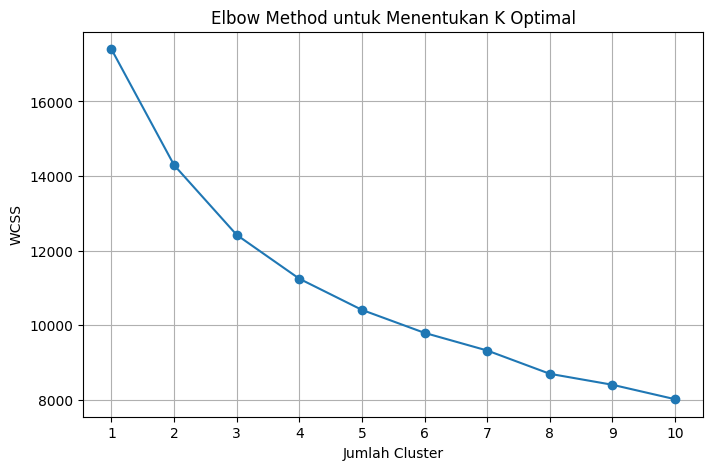

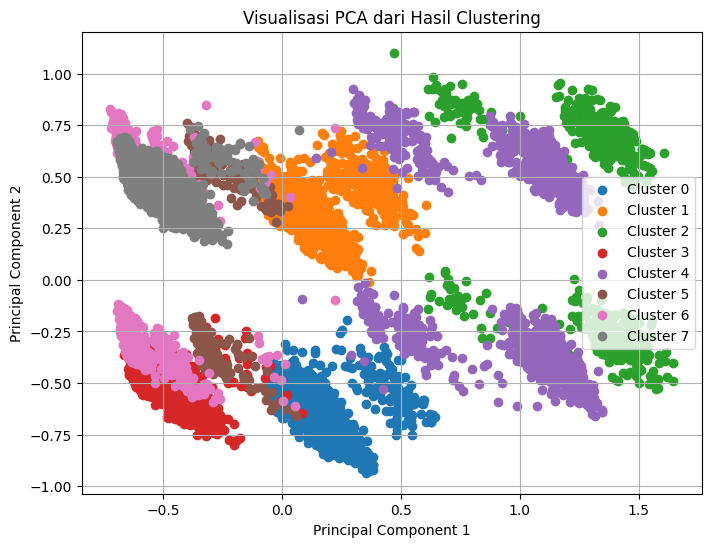

In [ ]:
# Visualisasi Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='-')
plt.xlabel("Jumlah Cluster")
plt.ylabel("WCSS")
plt.title("Elbow Method untuk Menentukan K Optimal")
plt.xticks(K_range)
plt.grid()
plt.show()

# Visualisasi hasil clustering dengan PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_scaled)
df_pca = pd.DataFrame(data=principal_components, columns=["PC1", "PC2"])
df_pca["Cluster"] = cluster_labels

plt.figure(figsize=(8, 6))
for cluster in range(total_clusters):
    plt.scatter(df_pca[df_pca["Cluster"] == cluster]["PC1"],
                df_pca[df_pca["Cluster"] == cluster]["PC2"],
                label=f'Cluster {cluster}')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Visualisasi PCA dari Hasil Clustering")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Evaluasi hasil clustering dengan Silhouette Score
silhouette_avg = silhouette_score(df_scaled, cluster_labels)
print(f"Silhouette Score: {silhouette_avg:.4f}")

print("Proses segmentasi selesai. Data disimpan dalam clustered_data_nasabah.csv")

Silhouette Score: 0.2127
Proses segmentasi selesai. Data disimpan dalam clustered_data_nasabah.csv
